In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Obesity_Data_clean.csv")
# ===== 3. 删除四个特征 =====
drop_cols = ["weight", "gender", "height", "family_history", "age"]
df = df.drop(columns=drop_cols)
print('Dataset shape:', df.shape)
df.head()
df.info()

Dataset shape: (2087, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   high_cal_food      2087 non-null   object 
 1   veg_consumption    2087 non-null   float64
 2   meals_per_day      2087 non-null   float64
 3   snacking           2087 non-null   object 
 4   smoking            2087 non-null   object 
 5   water_intake       2087 non-null   float64
 6   calorie_monitor    2087 non-null   object 
 7   physical_activity  2087 non-null   float64
 8   screen_time        2087 non-null   float64
 9   alcohol            2087 non-null   object 
 10  transport          2087 non-null   object 
 11  obesity_level      2087 non-null   object 
dtypes: float64(5), object(7)
memory usage: 195.8+ KB


obesity_level
Insufficient_Weight    267
Normal_Weight          282
Overweight_Level_I     276
Overweight_Level_II    290
Obesity_Type_I         351
Obesity_Type_II        297
Obesity_Type_III       324
Name: count, dtype: int64


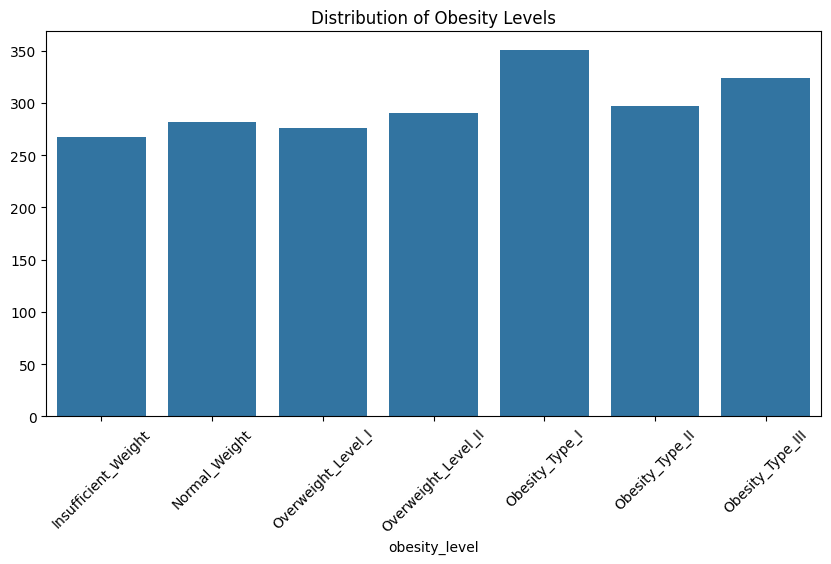

In [5]:
# 1. 定义肥胖程度顺序（从最瘦到最胖）
severity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]
#将字符串类型转换成有序分类
df['obesity_level'] = pd.Categorical(df['obesity_level'], categories=severity_order, ordered=True)

counts = df['obesity_level'].value_counts (sort=False)#不按数量排序
print(counts)
plt.figure(figsize=(10,5))
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Levels')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
X = df.drop('obesity_level', axis=1)
y = df['obesity_level']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Features shape: (2087, 11)
Target shape: (2087,)
Training set size: (1669, 11)
Test set size: (418, 11)


In [14]:
from sklearn.preprocessing import StandardScaler
# 数值型列
numeric_cols = ['physical_activity', 'screen_time']

# 类别型列
categorical_cols = X_train.columns.difference(numeric_cols)

# 对类别型列做独热编码
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# 确保训练集和测试集列完全一致
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# 标准化数值列
scaler = StandardScaler()
X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

In [16]:
import warnings
warnings.filterwarnings('ignore')#忽略警告信息
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score

from sklearn.model_selection import GridSearchCV #交叉验证寻找最佳超参数
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg']
}
lrmodel = LogisticRegression(max_iter=2000, random_state=2)
grid_lrmodel = GridSearchCV(lrmodel, param_grid, cv=5, scoring='f1_macro')
grid_lrmodel.fit(X_train_encoded, y_train)

best_lrmodel = grid_lrmodel.best_estimator_
y_pred_model = best_lrmodel.predict(X_test_encoded)
accuracy = accuracy_score(y_test, y_pred_model)
f1score = f1_score(y_test, y_pred_model, average='weighted')

print("Logistic Regression Accuracy:", accuracy)
print(f"Logistic Regression F1-score (weighted): {f1score:.4f}")


Logistic Regression Accuracy: 0.507177033492823
Logistic Regression F1-score (weighted): 0.4910


In [19]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
dt = DecisionTreeClassifier(class_weight='balanced', random_state=2)
param_grid = {
    'max_depth': [12, 15, 18, 20, None],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 4]
}
grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring='f1_weighted')
grid_dt.fit(X_train_encoded, y_train)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_encoded)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree Accuracy:", accuracy_dt)
print(f"Decision Tree F1-score (weighted): {f1_dt:.4f}")

Decision Tree Accuracy: 0.6698564593301436
Decision Tree F1-score (weighted): 0.6652


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# ===== 训练集和测试集已经独热编码并标准化 =====
# X_train_encoded, X_test_encoded 已经处理好

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
}
rf = RandomForestClassifier(random_state=2)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1_weighted', n_jobs=1)
grid.fit(X_train_encoded, y_train)

best_rf = grid.best_estimator_

# 使用编码后的测试集预测
y_pred = best_rf.predict(X_test_encoded)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Random Forest Accuracy: {acc:.4f}")
print(f"Random Forest F1-score (weighted): {f1:.4f}")

Random Forest Accuracy: 0.6029
Random Forest F1-score (weighted): 0.5898


XGBoost Accuracy: 0.6698564593301436
XGBoost F1-score (weighted): 0.6685


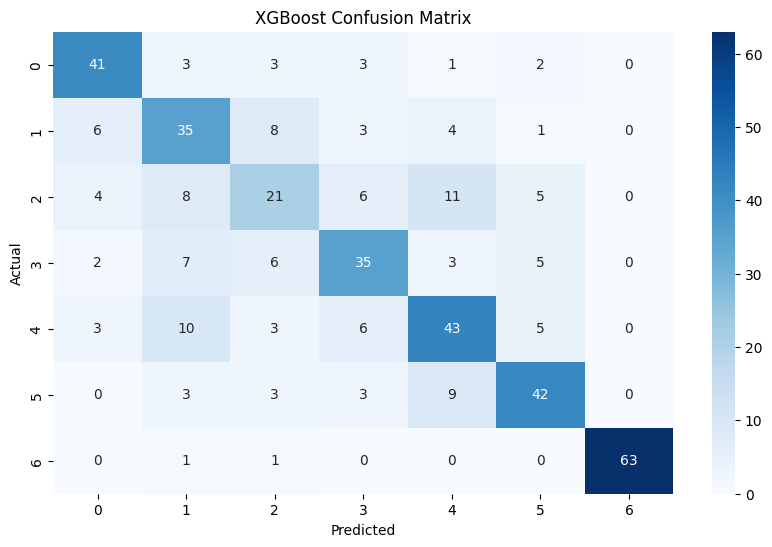

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 特征编码 =====
numeric_cols = ['physical_activity', 'screen_time']
categorical_cols = X_train.columns.difference(numeric_cols)

# 独热编码类别特征
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# 对测试集列与训练集列对齐
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# 标准化数值列
scaler = StandardScaler()
X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

# ===== 标签编码 =====
# 先确保是 category 类型，然后转换为整数
y_train_codes = y_train.astype('category').cat.codes
y_test_codes = y_test.astype('category').cat.codes

# ===== XGBoost 模型训练 =====
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=1
)
xgb.fit(X_train_encoded, y_train_codes)

# ===== 预测 =====
y_pred_xgb = xgb.predict(X_test_encoded)

# ===== 评价指标 =====
accuracy = accuracy_score(y_test_codes, y_pred_xgb)
f1_score_val = f1_score(y_test_codes, y_pred_xgb, average='weighted')

print("XGBoost Accuracy:", accuracy)
print(f"XGBoost F1-score (weighted): {f1_score_val:.4f}")

# 可选：混淆矩阵可视化
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test_codes, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

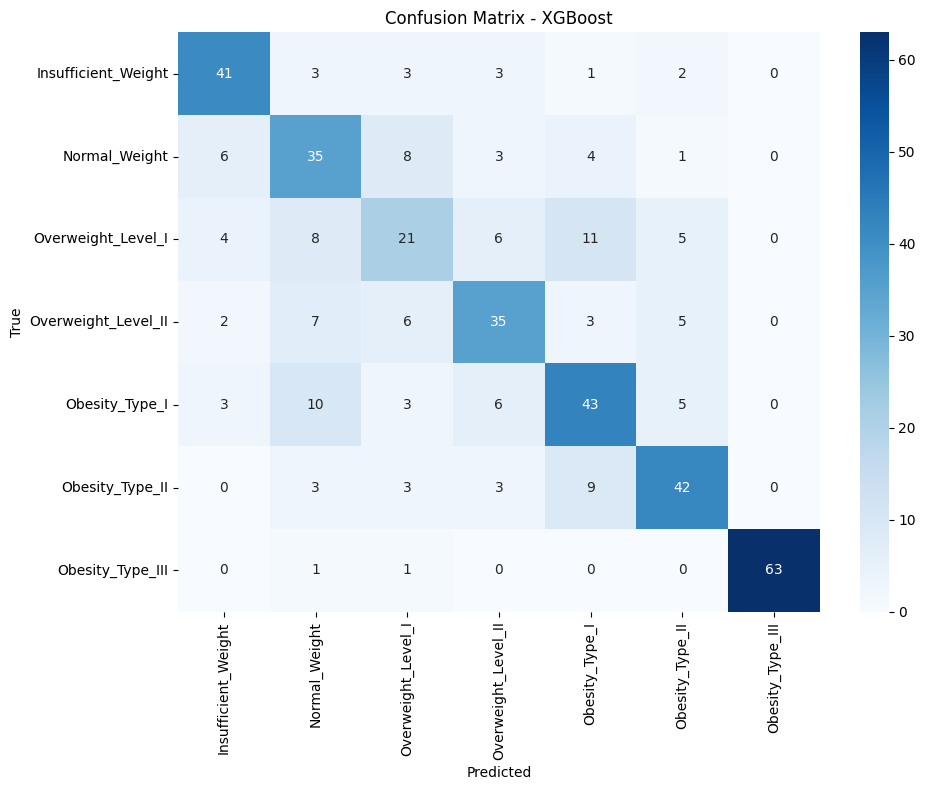


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.73      0.77      0.75        53
      Normal_Weight       0.52      0.61      0.56        57
 Overweight_Level_I       0.47      0.38      0.42        55
Overweight_Level_II       0.62      0.60      0.61        58
     Obesity_Type_I       0.61      0.61      0.61        70
    Obesity_Type_II       0.70      0.70      0.70        60
   Obesity_Type_III       1.00      0.97      0.98        65

           accuracy                           0.67       418
          macro avg       0.66      0.67      0.66       418
       weighted avg       0.67      0.67      0.67       418



In [29]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=severity_order, yticklabels=severity_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=severity_order))

Top 10 original features:
original_feature
veg                  0.237647
snacking             0.215659
alcohol              0.122188
transport            0.102120
water                0.095420
meals                0.074516
calorie              0.039554
screen_time          0.034513
high                 0.030045
physical_activity    0.029604
Name: importance, dtype: float32


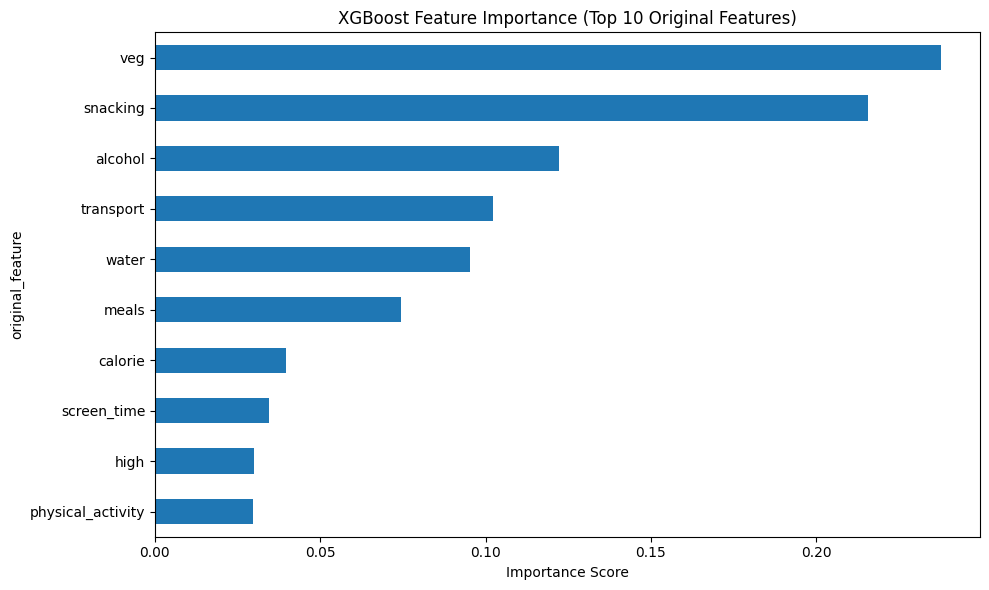

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 获取 XGBoost 特征重要性
importance = xgb.feature_importances_

# 创建 DataFrame 保存特征名和重要性
feat_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': importance
})

# ===== 汇总 one-hot 特征到原始特征 =====
# 假设 categorical 特征编码时用 pd.get_dummies，前缀是原始特征名
# 数值特征保持原名
numeric_cols = ['physical_activity', 'screen_time']

def get_original_feat(name):
    for col in numeric_cols:
        if name == col:
            return col
    # 如果是 one-hot 列名，取 "_" 前缀作为原始特征
    return name.split("_")[0]

feat_df['original_feature'] = feat_df['feature'].apply(get_original_feat)

# 按原始特征汇总重要性
feat_summary = feat_df.groupby('original_feature')['importance'].sum().sort_values(ascending=False)

# 显示前10个最重要的原始特征
print("Top 10 original features:")
print(feat_summary.head(10))

# 绘图
plt.figure(figsize=(10,6))
feat_summary.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (Top 10 Original Features)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()